In [1]:
import os
import shutil
if os.path.isdir("/Library/TeX/texbin"):                         # TeX Live on macOS
    os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib import rcParams
from math import sqrt, pi
from scipy.integrate import quad

rcParams.update({
    "text.usetex": shutil.which("latex") is not None,  # Use LaTeX for text (mathtext if LaTeX is not installed)
    "font.family": "serif",            # Use serif fonts
    "font.serif": ["Computer Modern"], # Default LaTeX font
    "axes.labelsize": 14,              # Axis label size
    "font.size": 13,                   # General font size
    "legend.fontsize": 12,             # Legend font size
    "xtick.labelsize": 12,             # X tick label size
    "ytick.labelsize": 12,             # Y tick label size
    "text.latex.preamble": r"\usepackage{amsmath,amssymb}"  # Optional packages
})

from scipy.special import gamma, gammainc
from scipy.integrate import quad
from scipy.special import hyp2f1

In [3]:
def langevin(a):
    a = np.asarray(a)
    out = np.empty_like(a, dtype=float)
    small = np.abs(a) < 1e-3

    # small-a expansion: L(a) ~ a/3 - a^3/45 + ...
    out[small] = a[small] / 3.0 * (1.0 - a[small]**2/15.0)

    # general case: L(a) = coth(a) - 1/a
    aa = a[~small]
    out[~small] = 1.0/np.tanh(aa) - 1.0/aa
    return out

In [4]:
def L_over_a(a):
    a = np.asarray(a)
    small = np.abs(a) < 1e-3
    out = np.empty_like(a, dtype=float)

    # For small a, L(a)/a -> 1/3 - a^2/45 + ...
    out[small] = 1.0/3.0 * (1.0 - a[small]**2/15.0)

    aa = a[~small]
    out[~small] = langevin(aa) / aa
    return out

In [5]:
def J_vs_sigma(v_star, sigma):
    prefac = 1.0 / (sqrt(2.0*pi) * sigma * v_star)

    def integrand(u):
        a = u * v_star / sigma**2
        gauss_part = np.exp(-(u - v_star)**2 / (2.0 * sigma**2)) \
                   - np.exp(-(u + v_star)**2 / (2.0 * sigma**2))
        return gauss_part * L_over_a(a)

    # Truncate at some finite upper limit where the Gaussians are tiny
    u_max = v_star + 6.0 * sigma
    val, err = quad(integrand, 0.0, u_max, epsabs=1e-8, epsrel=1e-6)
    return prefac * val

In [6]:
def S_mass(M, mass_cut):
    """
    Suppression factor:
        S(M) = (1 + mass_cut / M)^(-1)
    """
    return 1.0 / (1.0 + mass_cut / M)


def dNdM(M, M0, alpha, A):
    """
    Mass function:
        dN/dM = A * (M / M0)^(-alpha)
    """
    return A * (M / M0)**(-alpha)


def B_of_M_approx(M, B0):
    """
    Approximate B(M) using:
        B(M) ≈ B0 - ln(M)
    where B0 is treated as a constant parameter.
    """
    return B0 - np.log(M)


def mass_integrand(M, M0, alpha, A, B0, mass_cut):
    """
    Integrand for the mass part of D_II:
        integrand = (dN/dM) * M^2 * B(M) * S(M)
    with:
        dN/dM = A * (M / M0)^(-alpha)
        B(M) ≈ B0 - ln(M)
        S(M) = (1 + mass_cut / M)^(-1)
    """
    return dNdM(M, M0, alpha, A) * M**2 * B_of_M_approx(M, B0) * S_mass(M, mass_cut)


def mass_integral_quad(M_min, M_max, M0, alpha, A, B0, mass_cut):
    """
    Numerically evaluate:
        I = ∫_{M_min}^{M_max} dM (dN/dM) M^2 B(M) S(M)
    using scipy.integrate.quad.
    """
    I, err = quad(
        mass_integrand,
        M_min,
        M_max,
        args=(M0, alpha, A, B0, mass_cut),
        epsabs=0,
        epsrel=1e-5,
        limit=200
    )
    return I  # you can also return (I, err) if you care about the error

In [7]:
# Constants & fiducial parameters
G = 4.302e-6  # kpc (km/s)^2 / Msun
sigma = 200   # km/s, subhalo velocity dispersion (typical)
V0 = 230      # km/s, characteristic circular speed

alpha  = 1.9
M0     = 2.52e7
A      = 3.26e-5

In [8]:
# --- Aquarius Einasto parameters ---
alpha_E = 0.678
r200 = 210.0       # kpc
r_minus2 = 0.81 * r200

# --- Normalization constant ---
x200 = (2.0 / alpha_E) * (r200 / r_minus2)**alpha_E
s = 3.0 / alpha_E
N = (4 * np.pi * r_minus2**3 * np.exp(2/alpha_E)
     * (alpha_E/2)**(3/alpha_E) / alpha_E
     * gamma(s) * gammainc(s, x200))

def P(r):
    """Normalized Aquarius Einasto number-density profile (1/kpc^3)."""
    rho = np.exp(- (2/alpha_E) * ((r / r_minus2)**alpha_E - 1.0))
    return rho / N

In [9]:
def mass_integral(M_min, M_max, M_cut, alpha):
    """
    Computes ∫ M^(3-α)/(M + M_cut) dM from M_min to M_max,
    handling the M_cut=0 case explicitly.
    """
    # Special case: pure power-law (no cutoff)
    if M_cut == 0:
        if np.isclose(alpha, 3.0):
            return np.log(M_max / M_min)
        else:
            return (M_max**(3 - alpha) - M_min**(3 - alpha)) / (3 - alpha)
    
    # General case: M_cut > 0
    if np.isclose(alpha, 4.0):
        return (1/M_cut) * np.log((M_max*(M_min + M_cut)) / (M_min*(M_max + M_cut)))

    prefactor = 1.0 / (4.0 - alpha)
    term_max = M_max**(4 - alpha) * hyp2f1(1, 4 - alpha, 5 - alpha, -M_max / M_cut)
    term_min = M_min**(4 - alpha) * hyp2f1(1, 4 - alpha, 5 - alpha, -M_min / M_cut)
    return prefactor * (term_max - term_min)

In [10]:
def resonance_action(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = m*np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * ((R_res + R_bar)**5/(R_res**2)) * (V0**2)/2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_half = 4 * np.sqrt(epsilon / alpha)

    return Delta_I_half

## Differential (tidal) forces

Same treatment as in `diffusion_version2_tidal.ipynb`. The subhalo kick is taken **relative to the host mass enclosed by the orbit**, $\Delta\mathbf v_{\rm rel}=\Delta\mathbf v(\mathbf b)-\langle\Delta\mathbf v(\mathbf B_y)\rangle_y$, and the anisotropic (Fisher) encounter geometry is included. This enters $D_{II}$ only through the replacement $\mathcal B(M)\to\mathcal B_{\rm tid}(M)=\mathcal C(M)\,\mathcal B(M)$, with

$$\mathcal C(M)=\frac{\int du\,\frac{f(u)}{u}\langle S_{\rm tid}\rangle_{\xi(u)}}{\int du\,\frac{f(u)}{u}\langle S_{\rm fix}\rangle_{\xi(u)}},\qquad \xi = uv_*/\sigma^2 .$$

Use `force='tidal'` in `diffusion_coefficient` / `diffusion_timescale`; the default `force='fixed'` reproduces the original. The kernel table is cached (`tidalS_*.npz`), so it is computed once, in about 1–2 min.


In [11]:
import os
bmax = 210.0   # b_max = r200 [kpc]; used to invert B0 = ln(bmax^2/kappa) - 1 for the subhalo sizes
from scipy.interpolate import interp1d
_trapz = getattr(np, "trapezoid", None) or np.trapz   # numpy>=2 compatibility

TIDAL_GEOMETRY = 'aniso'     # 'aniso' (Fisher-weighted directions, default) or 'iso'

def _fib_sphere(n):
    i  = np.arange(n) + 0.5
    th = np.arccos(1 - 2*i/n); ph = np.pi*(1 + 5**0.5)*i
    return np.stack([np.sin(th)*np.cos(ph), np.sin(th)*np.sin(ph), np.cos(th)], 1)

def tidal_S_table(R_star, kappa_rs, logM_grid=np.linspace(2.5, 11.5, 37), b_max=210.,
                  n_dir=600, n_b=260, n_psi=40, n_centre=40, seed=1, cache=True):
    """
    Per-direction kernels S_fix(u_hat; M) and S_tid(u_hat; M)  [shape (n_dir, n_M)].
    Plummer-form kick, r_s^2 = kappa_rs*M.  Star at R_star*xhat, e_phi = yhat.
    S_tid uses the kick relative to the host mass enclosed by the orbit (|y|<R_star, dM ∝ dr).
    """
    fname = f"../data/tidalS_R{R_star:.3f}_k{kappa_rs:.3e}_n{n_dir}.npz"
    if cache and os.path.exists(fname):
        d = np.load(fname)
        if d["logM"].shape == logM_grid.shape and np.allclose(d["logM"], logM_grid):
            return 10**d["logM"], d["U"], d["S_fix"], d["S_tid"]
    Ms  = 10**logM_grid; rs2 = kappa_rs*Ms
    lnb = np.linspace(np.log(1e-3*np.sqrt(rs2.min())), np.log(b_max), n_b); b = np.exp(lnb)
    psi = np.linspace(0, 2*np.pi, n_psi, endpoint=False); dpsi = psi[1] - psi[0]
    xhat, ephi = np.array([1., 0, 0]), np.array([0, 1., 0])
    rng = np.random.default_rng(seed)
    Y   = ((np.arange(n_centre) + 0.5)/n_centre*R_star)[:, None] * _fib_sphere(n_centre)[rng.permutation(n_centre)]
    U   = _fib_sphere(n_dir)
    S_fix = np.zeros((n_dir, len(Ms))); S_tid = np.zeros_like(S_fix)
    w = (b**2)[None, :, None]                                   # d^2b = b^2 dln b dpsi
    for k, uh in enumerate(U):
        ref = np.array([0, 0, 1.]) if abs(uh[2]) < 0.9 else np.array([1., 0, 0])
        p = np.cross(uh, ref); p /= np.linalg.norm(p); q = np.cross(uh, p)
        perp = lambda v: v - (v @ uh)[..., None]*uh
        bv = b[:, None, None]*(np.cos(psi)[None, :, None]*p + np.sin(psi)[None, :, None]*q)
        X  = R_star*xhat + bv                                   # subhalo position at closest approach to star
        gs = (bv @ ephi)[None] / ((bv**2).sum(-1)[None] + rs2[:, None, None])
        gc = np.zeros_like(gs)
        for y in Y:                                             # mass-weighted kick on the enclosed host mass
            By = perp(X - y)
            gc += (By @ ephi)[None] / ((By**2).sum(-1)[None] + rs2[:, None, None])
        gc /= n_centre
        S_fix[k] = _trapz(((gs**2)*w).sum(-1)*dpsi, lnb, axis=1)
        S_tid[k] = _trapz((((gs - gc)**2)*w).sum(-1)*dpsi, lnb, axis=1)
    if cache: np.savez(fname, logM=logM_grid, U=U, S_fix=S_fix, S_tid=S_tid)
    return Ms, U, S_fix, S_tid

def _f_u(u, sig, vstar):
    """Relative-speed distribution f(u), Eq. 53 / B5."""
    return u/(sig*vstar*np.sqrt(2*np.pi))*(np.exp(-(u - vstar)**2/(2*sig**2)) - np.exp(-(u + vstar)**2/(2*sig**2)))

def _fisher_weights(U, xi):
    """Fisher (von Mises-Fisher) weights of the direction grid about e_phi; S(u)=S(-u) so the sign is irrelevant."""
    mu = U[:, 1]                                                # e_phi . u_hat
    wts = np.exp(-xi*(mu + 1.0)) if xi > 0 else np.ones(len(U)) # shifted exponent: no overflow
    return wts/wts.sum()

def aniso_correction(U, S_fix, S_tid, sig, vstar, n_u=400):
    """C(M) = ∫du f/u <S_tid>_xi / ∫du f/u <S_fix>_xi,  xi = u v*/sigma^2."""
    ug = np.linspace(1e-3, vstar + 7*sig, n_u); wu = _f_u(ug, sig, vstar)/ug
    num = np.zeros(S_fix.shape[1]); den = np.zeros(S_fix.shape[1])
    for ui, w_ in zip(ug, wu):
        W = _fisher_weights(U, ui*vstar/sig**2)
        num += w_*(W @ S_tid); den += w_*(W @ S_fix)
    return num/den

_B_tid_cache = {}
def B_tidal_func(R_res, B0, geometry=None, sig=None, vstar=None):
    """Interpolant M -> B_tid(M) for resonance radius R_res, with r_s set by the same B0 as the fixed curve."""
    geometry = TIDAL_GEOMETRY if geometry is None else geometry
    sig   = sigma if sig is None else sig
    vstar = V0    if vstar is None else vstar
    key = (round(R_res, 4), round(B0, 4), geometry, sig, vstar)
    if key not in _B_tid_cache:
        kappa_rs = bmax**2 * np.exp(-(B0 + 1))                  # inverts B0 = ln(bmax^2/kappa) - 1
        Ms, U, Sf, St = tidal_S_table(R_res, kappa_rs)
        B_fix_num = 3/np.pi*Sf.mean(0)
        chk = np.max(np.abs(B_fix_num - (B0 - np.log(Ms)))[Ms < 1e9])
        xi_t = 2.0; sep = (_fisher_weights(U, xi_t) @ Sf)[0]/Sf.mean(0)[0]
        if geometry == 'aniso':
            C  = aniso_correction(U, Sf, St, sig, vstar)
            Bt = B_fix_num*C
        elif geometry == 'iso':
            C  = St.mean(0)/Sf.mean(0)
            Bt = 3/np.pi*St.mean(0)
        else:
            raise ValueError("geometry must be 'aniso' or 'iso'")
        print(f"[tidal kernel] R_res={R_res:.3f} kpc, B0={B0:.2f}, {geometry}, sigma={sig}: "
              f"max|B_fix(num) - (B0 - ln M)| = {chk:.3f};  <S_fix>_xi=2 / iso = {sep:.4f} (3*lambda = {3*L_over_a(np.array([xi_t]))[0]:.4f})")
        f = interp1d(np.log(Ms), np.log(Bt), kind='linear', fill_value='extrapolate')
        _B_tid_cache[key] = lambda M, f=f: np.exp(f(np.log(M)))
        _B_tid_cache[key + ('C',)] = (Ms, C)
    return _B_tid_cache[key]

def mass_integral_quad_B(M_min, M_max, M0, alpha, A, B_func, mass_cut):
    """As mass_integral_quad, but with an arbitrary geometric factor B_func(M)."""
    f   = lambda M: dNdM(M, M0, alpha, A) * M**2 * B_func(M) * S_mass(M, mass_cut)
    pts = [10.**k for k in range(3, 12) if M_min < 10.**k < M_max]
    I, err = quad(f, M_min, M_max, epsabs=0, epsrel=1e-5, limit=400, points=pts or None)
    return I


In [12]:
def diffusion_coefficient(m_resonance, n_resonance, pattern_speed, mass_min, mass_max, mass_cut, impact_max, type, f_sup, force='fixed'):
    results = []
    for mass_max_i in np.atleast_1d(mass_max):
        b_max   = impact_max
        n       = n_resonance
        m       = m_resonance
        omega_p = pattern_speed

        # b-min
        m_min = 10**mass_min  # M_sun
        m_max = 10**mass_max_i  # M_sun

        R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

        # B term
        if type == 'P':
            #mass_int = mass_integral(m_min, m_max, M0, alpha, A, B0=27.15)
            B0_type = 27.15
        if type == 'H':
            #mass_int = mass_integral(m_min, m_max, M0, alpha, A, B0=28.02)
            B0_type = 28.02

        if force == 'fixed':      # galactic centre held fixed (as in the submitted paper)
            mass_int = mass_integral_quad(m_min, m_max, M0, alpha, A, B0=B0_type, mass_cut=10**mass_cut)
        elif force == 'tidal':    # kick relative to the host mass enclosed by the orbit
            mass_int = mass_integral_quad_B(m_min, m_max, M0, alpha, A,
                                            B_func=B_tidal_func(R_res, B0_type), mass_cut=10**mass_cut)
        else:
            raise ValueError("force must be 'fixed' or 'tidal'")
        P_res = f_sup*P(R_res)

        # Pre-factor
        prefactor = 2*np.pi * G**2 * (R_res/m)**2

        D = prefactor*mass_int*P_res*J_vs_sigma(V0, sigma)
        results.append(D)

    return np.array(results)


def diffusion_timescale(m_resonance, n_resonance, pattern_speed, radius_bar, strength_bar, mass_min, mass_max, mass_cut, impact_max, type, f_sup, force='fixed'):

    n       = n_resonance
    m       = m_resonance
    omega_p = pattern_speed
    R_bar   = radius_bar
    f_bar   = strength_bar

    # For a flat rotation curve, the resonance radius is given by
    R_res = (V0 / omega_p)*(1 + (n/m)*np.sqrt(2))   # kpc

    # For a flat rotation curve in an axisymmetric potential, one finds approximately
    # alpha = dOmega_phi/dLz ~ 1/R^2.
    alpha = m*np.abs(m+n*np.sqrt(2)) / R_res**2
    
    # And we set the effective bar strength parameter epsilon to be:
    #epsilon = f_bar * V0**2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2
    epsilon = f_bar * ((R_res + R_bar)**5/(R_res**2)) * (V0**2)/2 * (R_res**2) / (R_res + R_bar)**5 # (km/s)^2

    # Then the resonance (pendulum) full width in the action is:
    Delta_I_half = 2 * np.sqrt(4*epsilon / alpha)

    t_diff = (Delta_I_half)**2 / (2*diffusion_coefficient(m_resonance, n_resonance, pattern_speed, mass_min, mass_max, mass_cut, impact_max, type, f_sup, force=force))
    t_lib  = (2*np.pi)/np.sqrt(alpha*epsilon)

    #print(f't_diff = {t_diff}')

    return [t_diff, (4/np.pi)*(t_lib/t_diff)]

    

In [13]:
F1, F2 = 1/3, 1/6    # density scalings of P(r_CR) shown in the figures

M = np.linspace(5,10, 100)

D_list_cdm     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1)
delta_list_cdm = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=1)

D_list_cdm_f1     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=F1)
delta_list_cdm_f1 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=F1)

D_list_cdm_f2     = diffusion_coefficient(m_resonance=2, n_resonance=0, pattern_speed = 40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', f_sup=F2)
delta_list_cdm_f2 = diffusion_timescale(m_resonance=2, n_resonance=0, pattern_speed = 40, radius_bar=1.6, strength_bar=0.02, mass_min=3, mass_max=M, mass_cut=0, impact_max=200,type='P', f_sup=F2)

# --- same, with kicks relative to the host (differential forces)
kw = dict(m_resonance=2, n_resonance=0, pattern_speed=40, mass_min=3, mass_max=M, mass_cut=0, impact_max=200, type='P', force='tidal')
kt = dict(radius_bar=1.6, strength_bar=0.02, **kw)
D_list_cdm_tid    = diffusion_coefficient(f_sup=1,  **kw);  delta_list_cdm_tid    = diffusion_timescale(f_sup=1,  **kt)
D_list_cdm_f1_tid = diffusion_coefficient(f_sup=F1, **kw);  delta_list_cdm_f1_tid = diffusion_timescale(f_sup=F1, **kt)
D_list_cdm_f2_tid = diffusion_coefficient(f_sup=F2, **kw);  delta_list_cdm_f2_tid = diffusion_timescale(f_sup=F2, **kt)


[tidal kernel] R_res=5.750 kpc, B0=27.15, aniso, sigma=200: max|B_fix(num) - (B0 - ln M)| = 0.001;  <S_fix>_xi=2 / iso = 0.8060 (3*lambda = 0.8060)


In [14]:
from matplotlib.lines import Line2D

def _vis(x, *arrays, xlim=(1e5, 1e9)):
    """Positive values of arrays inside the plotted x-range (for axis limits)."""
    m = (x >= xlim[0]) & (x <= xlim[1])
    v = np.concatenate([np.atleast_1d(a)[m] for a in arrays])
    return v[np.isfinite(v) & (v > 0)]

force_legend = [Line2D([], [], color='k', lw=1.5, label=r'relative to host (differential force)'),
                Line2D([], [], color='k', lw=1.5, alpha=0.3, label=r'fixed galactic centre')]
frac = lambda f: r'$\tfrac{1}{%d}\times$ CDM' % round(1/f)


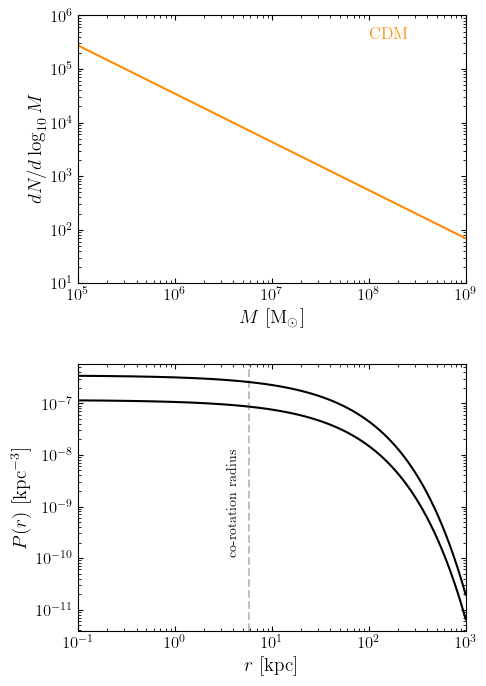

In [15]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(5, 8),
    gridspec_kw={'hspace': 0.3}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)

M = np.logspace(5,9,100)
dndm = A*(M/M0)**(-alpha)
ax1.plot(M, np.log(10)*M*dndm, color='darkorange')
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')
ax1.set_ylabel(r'$dN / d \log_{10} M$')

r = np.logspace(-1,3,100)
ax2.plot(r, P(r), color='k')
ax2.plot(r, (1/3)*P(r), color='k')
ax2.set_xlabel('$r$ [kpc]')
ax2.set_ylabel('$P(r)$ [kpc$^{-3}$]')

ax2.axvline(V0/40, color='k', linestyle='--', alpha=0.25)
ax2.text(
    10**0.6, 1e-10,                        
    'co-rotation radius',       # text
    ha='center', va='bottom',        
    fontsize=10, color='k',           
    rotation='vertical'
)

ax1.text(
    0.8, 0.9,                        
    r'CDM',
    transform=ax1.transAxes,
    ha='center', va='bottom',        
    fontsize=12, color='darkorange',           
)

ax1.set_xlim(10**5, 10**9)
ax1.set_ylim(10, 10**6)
ax2.set_xlim(10**-1, 10**3)

#plt.savefig('../figures/dark_matter_properties.pdf', dpi=400, bbox_inches='tight')
plt.show()

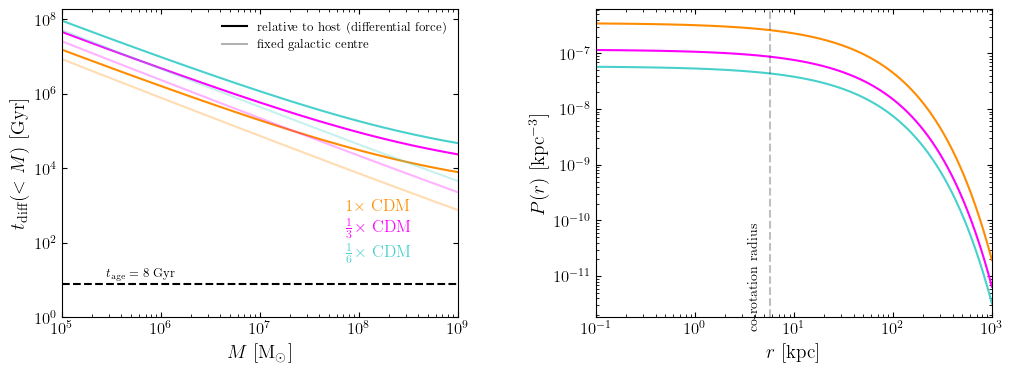

In [16]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4),
    gridspec_kw={'wspace': 0.35}  # directly set spacing here
)

for axis in (ax1, ax2):
    axis.set_rasterization_zorder(10)
    axis.set_xscale('log')
    axis.set_yscale('log')
    axis.tick_params(axis='both', which='both',
                   direction='in', top=True, right=True)
ax1.set_xlim(1e5,1e9)
ax2.set_xlim(10**-1, 10**3)
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')

M = np.linspace(5,10, 100)

curves = [(delta_list_cdm,    delta_list_cdm_tid,    'darkorange',      '-'),
          (delta_list_cdm_f1, delta_list_cdm_f1_tid, 'magenta',         '-'),
          (delta_list_cdm_f2, delta_list_cdm_f2_tid, 'mediumturquoise', '-')]
for dl_f, dl_t, col, ls in curves:
    ax1.plot(10**M, dl_f[0], color=col, linestyle=ls, alpha=0.3)   # fixed centre
    ax1.plot(10**M, dl_t[0], color=col, linestyle=ls)              # differential force
vt = _vis(10**M, *[c[0][0] for c in curves], *[c[1][0] for c in curves])
ax1.set_ylim(min(1.0, 0.5*vt.min()), 2*vt.max())

ax1.set_ylabel(r'$t_{\rm diff}(<M)$ [Gyr]')

ax1.axhline(8.0, linestyle='--', c='k')
ax1.text(10**5.8, 10, r'$t_{\rm age} = 8$ Gyr', ha='center', va='bottom', fontsize=9, color='k')

ax1.text(0.8, 0.34, r'$1 \times$ CDM', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='darkorange')
ax1.text(0.8, 0.26, frac(F1),           transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='magenta')
ax1.text(0.8, 0.18, frac(F2),           transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='mediumturquoise')
ax1.legend(handles=force_legend, loc='upper right', fontsize=9, frameon=False)

r = np.logspace(-1,3,100)
ax2.plot(r, P(r), color='darkorange')
ax2.plot(r, F1*P(r), color='magenta')
ax2.plot(r, F2*P(r), color='mediumturquoise')
ax2.set_xlabel('$r$ [kpc]')
ax2.set_ylabel('$P(r)$ [kpc$^{-3}$]')

ax2.text(10**0.6, 1e-12, 'co-rotation radius', ha='center', va='bottom', fontsize=10, color='k', rotation='vertical')
ax2.axvline(V0/40, color='k', linestyle='--', alpha=0.25)

#plt.savefig('../figures/suppression_constraints_tidal.pdf', dpi=400, bbox_inches='tight')
plt.show()


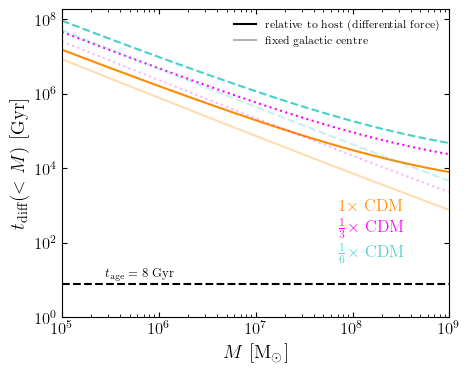

In [17]:
fig, ax1 = plt.subplots(
    1, 1, figsize=(5, 4),
    gridspec_kw={'wspace': 0.35}  # directly set spacing here
)

ax1.set_rasterization_zorder(10)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.tick_params(axis='both', which='both',
                direction='in', top=True, right=True)

ax1.set_xlim(1e5,1e9)
ax1.set_xlabel(r'$M$ [M$_{\odot}$]')

M = np.linspace(5,10, 100)

curves = [(delta_list_cdm,    delta_list_cdm_tid,    'darkorange',      '-'),
          (delta_list_cdm_f1, delta_list_cdm_f1_tid, 'magenta',         ':'),
          (delta_list_cdm_f2, delta_list_cdm_f2_tid, 'mediumturquoise', '--')]
for dl_f, dl_t, col, ls in curves:
    ax1.plot(10**M, dl_f[0], color=col, linestyle=ls, alpha=0.3)   # fixed centre
    ax1.plot(10**M, dl_t[0], color=col, linestyle=ls)              # differential force
vt = _vis(10**M, *[c[0][0] for c in curves], *[c[1][0] for c in curves])
ax1.set_ylim(min(1.0, 0.5*vt.min()), 2*vt.max())

ax1.set_ylabel(r'$t_{\rm diff}(<M)$ [Gyr]')

ax1.axhline(8.0, linestyle='--', c='k')
ax1.text(10**5.8, 10, r'$t_{\rm age} = 8$ Gyr', ha='center', va='bottom', fontsize=9, color='k')

ax1.text(0.8, 0.34, r'$1 \times$ CDM', transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='darkorange')
ax1.text(0.8, 0.26, frac(F1),           transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='magenta')
ax1.text(0.8, 0.18, frac(F2),           transform=ax1.transAxes, ha='center', va='bottom', fontsize=12, color='mediumturquoise')
ax1.legend(handles=force_legend, loc='upper right', fontsize=8, frameon=False)

#plt.savefig('../figures/suppression_constraints_tidal.pdf', dpi=400, bbox_inches='tight')
plt.show()


### Density enhancement needed to erase the resonance

Since $D_{II}\propto P(r_{\rm CR})$, the diffusion timescale scales exactly as $t_{\rm diff}\propto 1/f$ for a density scaling $f$. The subhalo density at co-rotation would therefore have to be $f_{\rm erase}(M)=t_{\rm diff}(<M;f{=}1)/t_{\rm age}$ times the CDM value for subhaloes up to mass $M$ to erase the resonance within $t_{\rm age}$. Values of $f_{\rm erase}>1$ mean the CDM population is too sparse to do so.


In [18]:
t_age = 8.0
for Mcut in [1e7, 1e8, 1e9, 1e10]:
    j = np.argmin(abs(10**M - Mcut))
    print(f"M < {Mcut:.0e}:  f_erase (fixed centre) = {delta_list_cdm[0][j]/t_age:10.3g}   "
          f"f_erase (differential force) = {delta_list_cdm_tid[0][j]/t_age:10.3g}")


M < 1e+07:  f_erase (fixed centre) =   8.94e+03   f_erase (differential force) =   2.37e+04
M < 1e+08:  f_erase (fixed centre) =        966   f_erase (differential force) =   4.02e+03
M < 1e+09:  f_erase (fixed centre) =       98.4   f_erase (differential force) =   1.01e+03
M < 1e+10:  f_erase (fixed centre) =       11.1   f_erase (differential force) =        427
